# Reasoning as Bargaining: A Nash-Inspired Scheduler for AI Subagents

## Game Theory Final Project Notebook

This notebook implements a simple simulation of **Adaptive Strategic Reasoning Architecture (ASRA)**.

The main idea is to model reasoning subagents as players in a cooperative bargaining game. Each subagent competes for a limited reasoning budget, and the scheduler decides how much budget each subagent receives.

This project is inspired by the paper **Multi-Task Learning as a Bargaining Game**, where machine learning tasks bargain over a shared gradient update direction. Here, we adapt the same high-level idea to reasoning systems: instead of tasks bargaining over model updates, reasoning subagents bargain over limited reasoning resources.

## Core Question

Can a Nash-inspired bargaining allocation produce a better balance between total utility and fairness than equal allocation or greedy allocation?

## Game Theory Setup

| Game Theory Concept | ASRA Version |
|---|---|
| Players | Reasoning subagents |
| Resource | Fixed reasoning budget |
| Strategy / Agreement | How much budget each agent receives |
| Utility | Expected usefulness of an agent minus cost |
| Disagreement Point | Minimum/default value if no useful allocation happens |
| Solution Concept | Nash-inspired bargaining allocation |

The four subagents in this simulation are:

1. **Planner**: breaks the task into steps  
2. **Researcher**: gathers or expands information  
3. **Critic**: finds weaknesses, gaps, and risks  
4. **Verifier**: checks correctness and consistency  

For the MVP, each agent receives a simple utility score:

```python
value = relevance + urgency + past_success - cost
```

Then we compare three allocation methods:

1. **Equal Allocation**: split the budget evenly  
2. **Greedy Allocation**: give most of the budget to the highest-value agents  
3. **Nash-Inspired Allocation**: allocate budget based on positive utility gain above disagreement point

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True

## 1. Define the Subagents

Each agent has a historical success value and a cost. These are fixed starting properties.

The task-specific values, like relevance and urgency, will change depending on the task.

In [2]:
agents = {
    "Planner": {
        "past_success": 0.80,
        "cost": 0.25,
        "description": "Breaks the task into steps and creates a strategy."
    },
    "Researcher": {
        "past_success": 0.70,
        "cost": 0.35,
        "description": "Gathers facts, context, and supporting information."
    },
    "Critic": {
        "past_success": 0.75,
        "cost": 0.30,
        "description": "Finds weaknesses, risks, and missing assumptions."
    },
    "Verifier": {
        "past_success": 0.78,
        "cost": 0.28,
        "description": "Checks accuracy, consistency, and correctness."
    }
}

pd.DataFrame(agents).T

,past_success,cost,description
Planner,0.8,0.25,Breaks the task into steps and creates a strat...
Researcher,0.7,0.35,"Gathers facts, context, and supporting informa..."
Critic,0.75,0.3,"Finds weaknesses, risks, and missing assumptions."
Verifier,0.78,0.28,"Checks accuracy, consistency, and correctness."


## 2. Define Example Tasks

Each task gives each agent a different relevance and urgency score.

For example, a research-heavy task should give the Researcher a high relevance score. A math-checking task should give the Verifier a high relevance score.

In [4]:
tasks = {
    "Easy Writing Task": {
        "Planner": {"relevance": 0.60, "urgency": 0.50},
        "Researcher": {"relevance": 0.20, "urgency": 0.20},
        "Critic": {"relevance": 0.50, "urgency": 0.40},
        "Verifier": {"relevance": 0.40, "urgency": 0.30},
    },
    "Research-Heavy Task": {
        "Planner": {"relevance": 0.70, "urgency": 0.60},
        "Researcher": {"relevance": 0.95, "urgency": 0.90},
        "Critic": {"relevance": 0.65, "urgency": 0.50},
        "Verifier": {"relevance": 0.75, "urgency": 0.70},
    },
    "Math Verification Task": {
        "Planner": {"relevance": 0.50, "urgency": 0.40},
        "Researcher": {"relevance": 0.25, "urgency": 0.20},
        "Critic": {"relevance": 0.70, "urgency": 0.65},
        "Verifier": {"relevance": 0.95, "urgency": 0.95},
    },
    "Planning Task": {
        "Planner": {"relevance": 0.95, "urgency": 0.90},
        "Researcher": {"relevance": 0.55, "urgency": 0.40},
        "Critic": {"relevance": 0.65, "urgency": 0.50},
        "Verifier": {"relevance": 0.45, "urgency": 0.35},
    },
    "Ambiguous Strategic Task": {
        "Planner": {"relevance": 0.85, "urgency": 0.80},
        "Researcher": {"relevance": 0.75, "urgency": 0.65},
        "Critic": {"relevance": 0.90, "urgency": 0.85},
        "Verifier": {"relevance": 0.70, "urgency": 0.65},
    },
}

## 3. Utility Function

This function calculates each agent's value for a given task.

The formula is intentionally simple for the prototype:

```python
value = relevance + urgency + past_success - cost
```

Higher value means the agent is more useful for that task.

In [5]:
def compute_agent_values(task_name):
    """Compute utility values for all agents for a selected task."""
    task = tasks[task_name]
    rows = []

    for agent_name, base in agents.items():
        relevance = task[agent_name]["relevance"]
        urgency = task[agent_name]["urgency"]
        past_success = base["past_success"]
        cost = base["cost"]
        value = relevance + urgency + past_success - cost

        rows.append({
            "agent": agent_name,
            "relevance": relevance,
            "urgency": urgency,
            "past_success": past_success,
            "cost": cost,
            "value": value
        })

    return pd.DataFrame(rows)

compute_agent_values("Research-Heavy Task")

,agent,relevance,urgency,past_success,cost,value
0,Planner,0.70,0.6,0.80,0.25,1.85
1,Researcher,0.95,0.9,0.70,0.35,2.20
2,Critic,0.65,0.5,0.75,0.30,1.60
3,Verifier,0.75,0.7,0.78,0.28,1.95


## 4. Allocation Methods

We compare three schedulers.

### Equal Allocation
Every agent gets the same budget.

### Greedy Allocation
Agents with higher value get disproportionately more budget.

### Nash-Inspired Allocation
Agents receive budget proportional to their positive utility gain above a disagreement point.

In a formal Nash bargaining problem, the solution maximizes:

```python
sum(log(utility_i - disagreement_i))
```

For this simple MVP, we use a lightweight version:

```python
nash_score_i = max(value_i - disagreement_i, epsilon)
allocation_i = nash_score_i / sum(nash_scores) * total_budget
```

This keeps the implementation simple while preserving the main bargaining intuition.

In [6]:
def equal_allocation(values_df, total_budget=100):
    n = len(values_df)
    return np.ones(n) * (total_budget / n)


def greedy_allocation(values_df, total_budget=100, temperature=3.0):
    """
    Greedy allocation using a softmax-style weighting.
    Higher temperature makes allocation more concentrated on high-value agents.
    """
    values = values_df["value"].to_numpy()
    exp_values = np.exp(temperature * values)
    weights = exp_values / exp_values.sum()
    return weights * total_budget


def nash_inspired_allocation(values_df, total_budget=100, disagreement=0.5, epsilon=0.01):
    """
    Simple Nash-inspired allocation.
    Agents are allocated resources based on utility gains above a disagreement point.
    """
    values = values_df["value"].to_numpy()
    gains = np.maximum(values - disagreement, epsilon)
    weights = gains / gains.sum()
    return weights * total_budget

## 5. Run One Example Task

This shows the allocation produced by each scheduler for one task.

In [7]:
def run_allocations_for_task(task_name, total_budget=100):
    values_df = compute_agent_values(task_name)

    result = values_df[["agent", "value"]].copy()
    result["Equal Allocation"] = equal_allocation(values_df, total_budget)
    result["Greedy Allocation"] = greedy_allocation(values_df, total_budget)
    result["Nash-Inspired Allocation"] = nash_inspired_allocation(values_df, total_budget)

    return result

example_result = run_allocations_for_task("Research-Heavy Task")
example_result

,agent,value,Equal Allocation,Greedy Allocation,Nash-Inspired Allocation
0,Planner,1.85,25.0,17.606017,24.107143
1,Researcher,2.20,25.0,50.311853,30.357143
2,Critic,1.60,25.0,8.316493,19.642857
3,Verifier,1.95,25.0,23.765637,25.892857


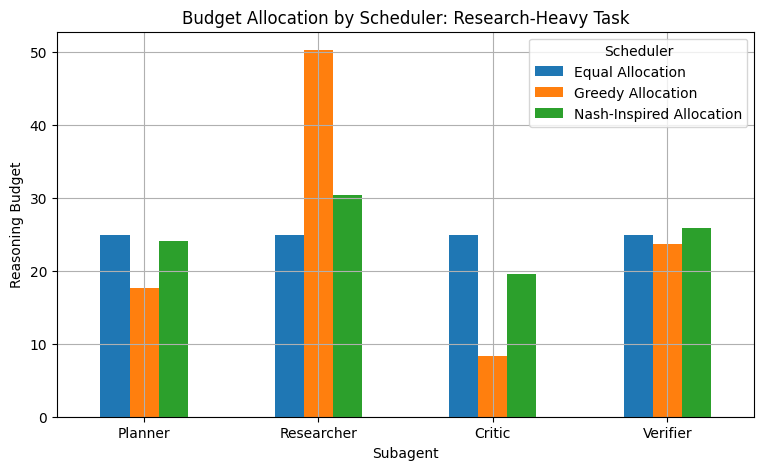

In [8]:
def plot_task_allocations(task_name):
    result = run_allocations_for_task(task_name)
    plot_df = result.set_index("agent")[["Equal Allocation", "Greedy Allocation", "Nash-Inspired Allocation"]]

    ax = plot_df.plot(kind="bar")
    ax.set_title(f"Budget Allocation by Scheduler: {task_name}")
    ax.set_ylabel("Reasoning Budget")
    ax.set_xlabel("Subagent")
    plt.xticks(rotation=0)
    plt.legend(title="Scheduler")
    plt.show()

plot_task_allocations("Research-Heavy Task")

## 6. Scheduling States: ACT, WAIT, PRUNE

After assigning budget, ASRA can convert budget levels into scheduling decisions.

Simple rule:

- **ACT**: budget is 25 or higher  
- **WAIT**: budget is between 10 and 25  
- **PRUNE**: budget is below 10

In [9]:
def assign_state(allocation):
    if allocation >= 25:
        return "ACT"
    elif allocation >= 10:
        return "WAIT"
    else:
        return "PRUNE"


def add_states(result_df):
    result = result_df.copy()
    for method in ["Equal Allocation", "Greedy Allocation", "Nash-Inspired Allocation"]:
        result[method + " State"] = result[method].apply(assign_state)
    return result

add_states(example_result)

,agent,value,Equal Allocation,Greedy Allocation,Nash-Inspired Allocation,Equal Allocation State,Greedy Allocation State,Nash-Inspired Allocation State
0,Planner,1.85,25.0,17.606017,24.107143,ACT,WAIT,WAIT
1,Researcher,2.20,25.0,50.311853,30.357143,ACT,ACT,ACT
2,Critic,1.60,25.0,8.316493,19.642857,ACT,PRUNE,WAIT
3,Verifier,1.95,25.0,23.765637,25.892857,ACT,WAIT,ACT


## 7. Evaluate All Tasks

Now we run all example tasks and compare the three schedulers.

We use two simple metrics:

1. **Total Weighted Utility**: how much useful work the allocation produces  
2. **Fairness Score**: how evenly resources are distributed, using Jain's Fairness Index  

Jain's Fairness Index ranges from 0 to 1. Higher means more balanced.

In [10]:
def total_weighted_utility(values, allocations):
    """Utility is modeled as value multiplied by allocated budget share."""
    budget_share = allocations / allocations.sum()
    return np.sum(values * budget_share)


def jains_fairness_index(allocations):
    """Jain's fairness index. Higher is more fair."""
    allocations = np.asarray(allocations)
    numerator = allocations.sum() ** 2
    denominator = len(allocations) * np.sum(allocations ** 2)
    return numerator / denominator


def evaluate_all_tasks():
    rows = []

    for task_name in tasks.keys():
        values_df = compute_agent_values(task_name)
        values = values_df["value"].to_numpy()

        methods = {
            "Equal Allocation": equal_allocation(values_df),
            "Greedy Allocation": greedy_allocation(values_df),
            "Nash-Inspired Allocation": nash_inspired_allocation(values_df),
        }

        for method_name, allocations in methods.items():
            rows.append({
                "task": task_name,
                "method": method_name,
                "total_weighted_utility": total_weighted_utility(values, allocations),
                "fairness_score": jains_fairness_index(allocations),
                "min_allocation": allocations.min(),
                "max_allocation": allocations.max()
            })

    return pd.DataFrame(rows)

evaluation_df = evaluate_all_tasks()
evaluation_df

,task,method,total_weighted_utility,fairness_score,min_allocation,max_allocation
0,Easy Writing Task,Equal Allocation,1.237500,1.000000,25.000000,25.000000
1,Easy Writing Task,Greedy Allocation,1.477403,0.606971,3.877952,57.702891
2,Easy Writing Task,Nash-Inspired Allocation,1.380508,0.837584,8.474576,38.983051
3,Research-Heavy Task,Equal Allocation,1.900000,1.000000,25.000000,25.000000
4,Research-Heavy Task,Greedy Allocation,2.029066,0.719378,8.316493,50.311853
5,Research-Heavy Task,Nash-Inspired Allocation,1.933036,0.976947,19.642857,30.357143
6,Math Verification Task,Equal Allocation,1.612500,1.000000,25.000000,25.000000
7,Math Verification Task,Greedy Allocation,2.264136,0.367766,0.668339,81.210164
8,Math Verification Task,Nash-Inspired Allocation,1.914045,0.786750,6.741573,42.696629
9,Planning Task,Equal Allocation,1.650000,1.000000,25.000000,25.000000


In [11]:
summary_df = evaluation_df.groupby("method")[["total_weighted_utility", "fairness_score"]].mean().sort_values(
    by="total_weighted_utility", ascending=False
)
summary_df

,total_weighted_utility,fairness_score
method,,
Greedy Allocation,2.029390,0.561343
Nash-Inspired Allocation,1.816235,0.890098
Equal Allocation,1.680000,1.000000


## 8. Visualization of Results

These plots compare the average performance of each scheduler across all sample tasks.

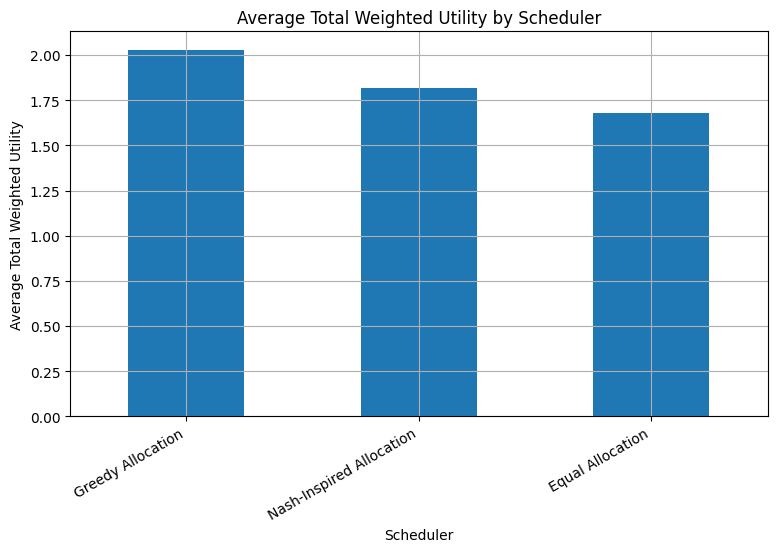

In [12]:
ax = summary_df["total_weighted_utility"].plot(kind="bar")
ax.set_title("Average Total Weighted Utility by Scheduler")
ax.set_ylabel("Average Total Weighted Utility")
ax.set_xlabel("Scheduler")
plt.xticks(rotation=30, ha="right")
plt.show()

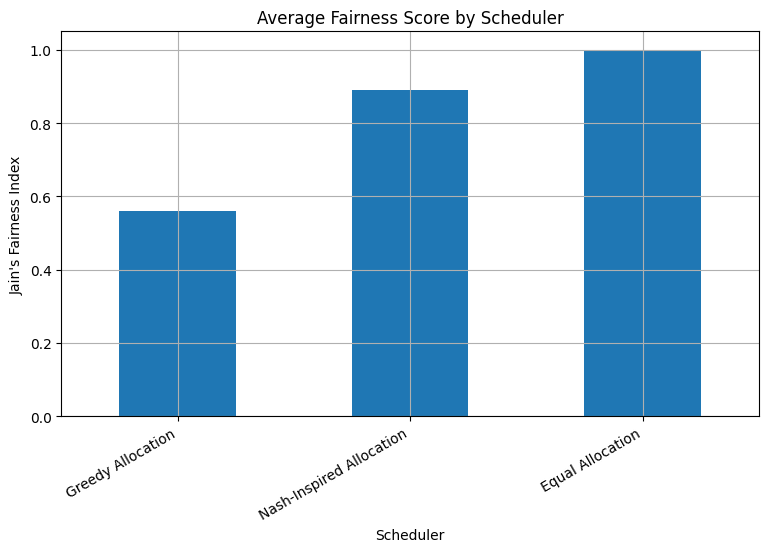

In [13]:
ax = summary_df["fairness_score"].plot(kind="bar")
ax.set_title("Average Fairness Score by Scheduler")
ax.set_ylabel("Jain's Fairness Index")
ax.set_xlabel("Scheduler")
plt.xticks(rotation=30, ha="right")
plt.show()

## 9. Allocation Charts for Every Task

These charts show how each scheduler behaves differently depending on task type.

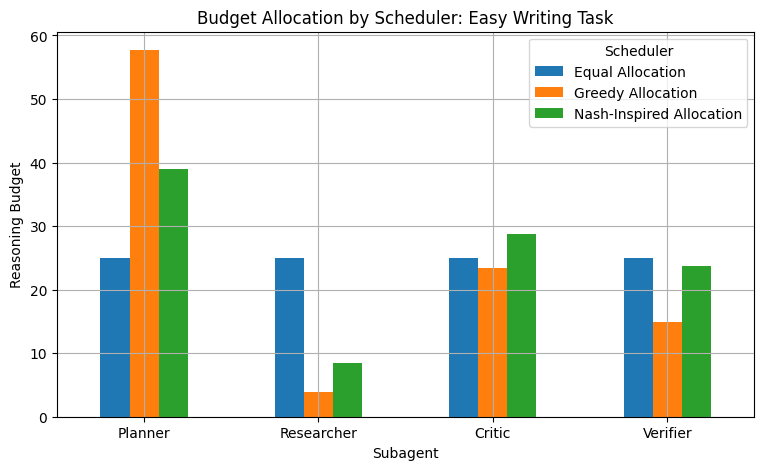

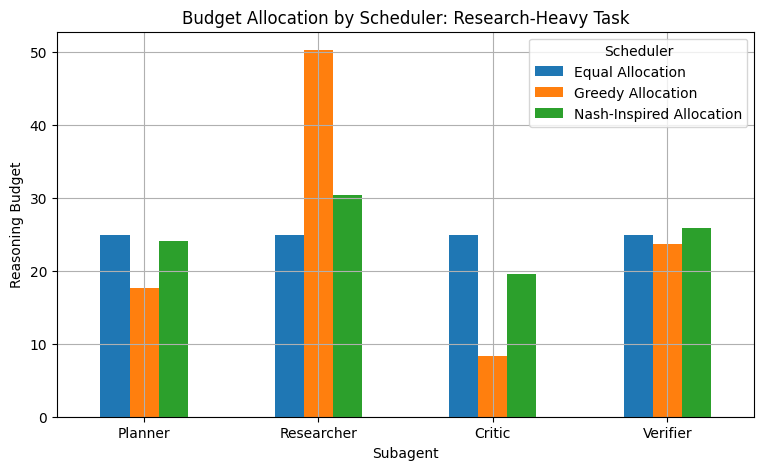

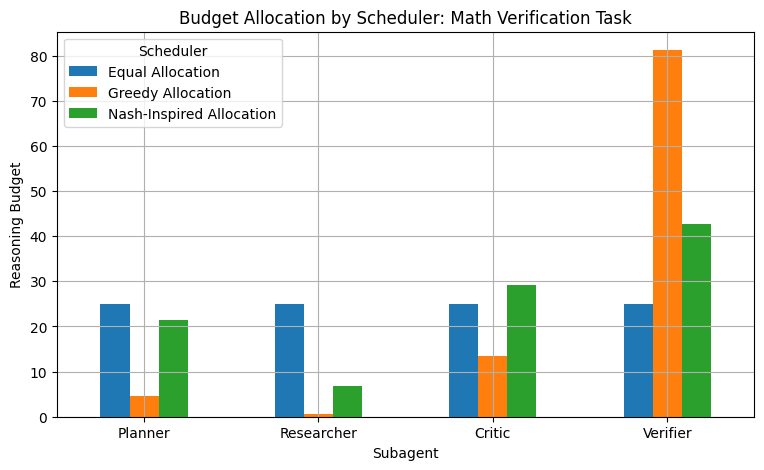

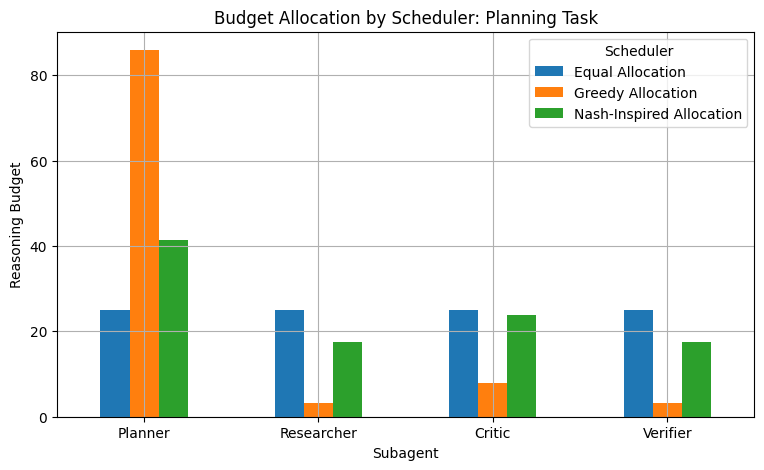

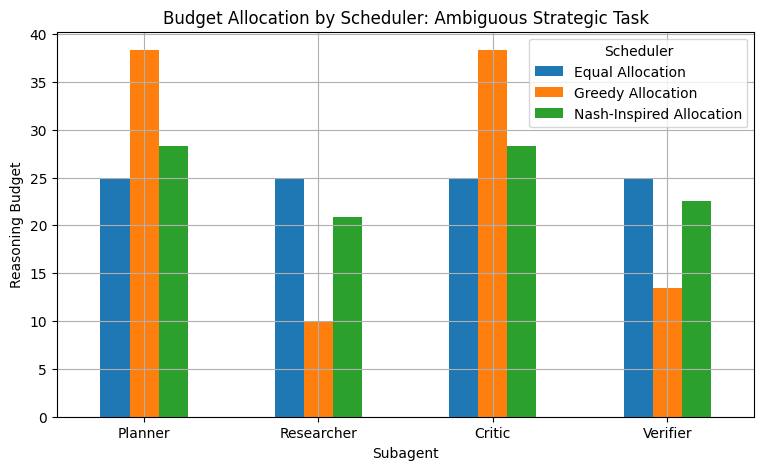

In [14]:
for task_name in tasks.keys():
    plot_task_allocations(task_name)

## 10. Interpretation

The equal scheduler is the most balanced, but it does not adapt to the task. It gives the same amount of reasoning budget to every agent, even when some agents are clearly more useful than others.

The greedy scheduler is more adaptive, but it can over-prioritize the highest-value agent. This may create imbalance because some useful agents receive very little budget.

The Nash-inspired scheduler is the best conceptual fit for this project because it balances two goals:

1. Give more resources to agents with higher expected usefulness.
2. Avoid letting one agent dominate the whole reasoning process.

This connects directly to cooperative bargaining in game theory. The scheduler acts like a bargaining solution over limited reasoning resources.

## 11. Final Project Summary

This notebook built a simple game-theoretic scheduler for ASRA: Adaptive Strategic Reasoning Architecture.

The system models reasoning subagents as players in a cooperative bargaining game. Each player has a utility value based on relevance, urgency, historical success, and cost. The system then allocates a fixed reasoning budget using three different approaches: equal allocation, greedy allocation, and a Nash-inspired bargaining allocation.

The main takeaway is that a bargaining-based scheduler can provide a middle ground between rigid equal allocation and overly aggressive greedy allocation. This makes it useful for reasoning systems where multiple subagents need to cooperate under limited computational resources.

## Possible Future Work

- Replace simulated utilities with real LLM output scores.
- Add memory so agent success changes over time.
- Use a formal optimization solver to maximize the full Nash bargaining objective.
- Test the scheduler on real multi-agent reasoning tasks.
- Add more agents, such as Executor, Summarizer, and Risk Analyst.